In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:

dataset_path = kagglehub.dataset_download("imtkaggleteam/drug-discovery-chemical-space-design")
import os

csv_files = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith('.csv'):
            csv_files.append(os.path.join(root, file))

# Load the first CSV
df = pd.read_csv(csv_files[0])

# Display the first few rows
df.head()


,ID,score,SMILES,target,MW,MW_EXACT,XLogP,HBA,HBD,LIPINSKI_COUNT,...,BondCount,FSP3,RotBondCount,HalogenCount,SpiroCount,PosCount,NegCount,ComponentCount,SimpleRingCount,AromaticRingCount
0,(DESMILES:6968009),-182.9720,C#Cc1ccccc1-c1c(/C(N)=N/O)cc(C(F)(F)F)cc1-c1cc...,ada,396.36,396.108551,5.95,4,3,1,...,31,0.045,4,3,0,0,0,1,3,3
1,(DESMILES:1090761),-172.2308,CCOC(=O)c1cn[nH]c1S(=O)(=O)NC(CN)C1CCCC1,ada,330.40,330.136169,1.68,8,3,0,...,23,0.692,8,0,0,0,0,1,2,1
2,"(DESMILES:11628423,DESMILES:152270,DESMILES:79...",-166.7088,Cn1cnc(Nc2nc(N[C@H](CNC(=O)O)c3ccc(F)cc3)nc(N3...,ada,457.46,457.198608,2.26,12,4,1,...,37,0.350,8,1,0,0,0,1,4,3
3,(DESMILES:1708673),-164.8812,Cc1ccc(Oc2ccc(Nc3ncnc4cc(CNC(=O)O)[nH]c34)cc2C...,ada,404.42,404.159698,2.18,9,4,0,...,33,0.143,6,0,0,0,0,1,4,4
4,"(DESMILES:2774222,DESMILES:6558061)",-164.5410,CC(NC(=O)O)[C@H](CC1CCCCC1)NC(=O)OC(C)(C)C,ada,314.42,314.220551,3.09,6,3,0,...,23,0.875,6,0,0,0,0,1,1,0


In [4]:
# Display basic information about the dataset
print("Dataset Info:\n")
df.info()

# Display column names
print("\nColumn Names:\n", df.columns.tolist())

# Check for missing values
print("\nMissing Values:\n")
print(df.isnull().sum())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 637292 entries, 0 to 637291
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ID                 637292 non-null  object 
 1   score              637292 non-null  float64
 2   SMILES             637292 non-null  object 
 3   target             637292 non-null  object 
 4   MW                 637292 non-null  float64
 5   MW_EXACT           637292 non-null  float64
 6   XLogP              637292 non-null  float64
 7   HBA                637292 non-null  int64  
 8   HBD                637292 non-null  int64  
 9   LIPINSKI_COUNT     637292 non-null  int64  
 10  RO3_COUNT          637292 non-null  int64  
 11  TPSA_NO            637292 non-null  float64
 12  TPSA_NOPS          637292 non-null  float64
 13  HAC                637292 non-null  int64  
 14  AtomCount          637292 non-null  int64  
 15  BondCount          637292 non-null  

In [5]:
# Drop rows with missing values (if any)
df_clean = df.dropna()

# Verify cleaning
print("\nShape before cleaning:", df.shape)
print("Shape after cleaning:", df_clean.shape)



Shape before cleaning: (637292, 25)
Shape after cleaning: (637292, 25)


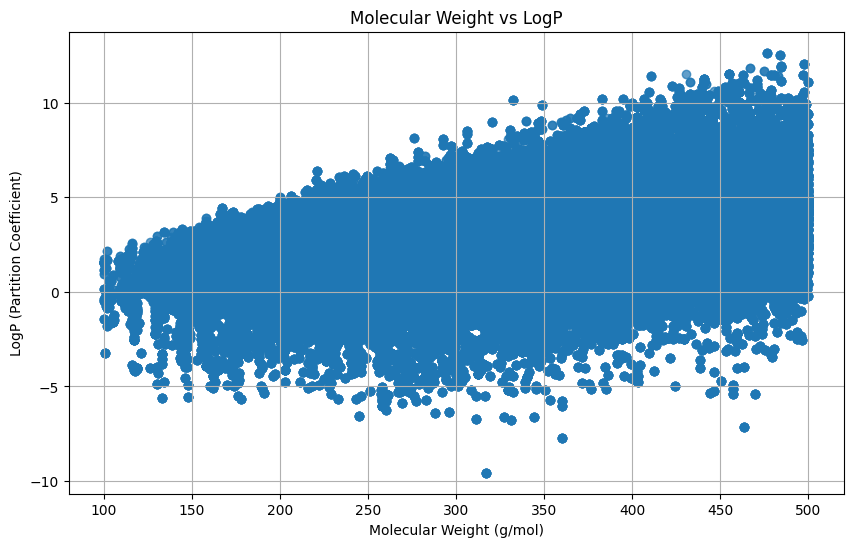

In [6]:
# Scatter plot for Molecular Weight vs LogP
if 'MW' in df_clean.columns and 'XLogP' in df_clean.columns:
    plt.figure(figsize=(10, 6))
    plt.scatter(df_clean['MW'], df_clean['XLogP'], alpha=0.7)
    plt.xlabel('Molecular Weight (g/mol)')
    plt.ylabel('LogP (Partition Coefficient)')
    plt.title('Molecular Weight vs LogP')
    plt.grid(True)
    plt.show()
else:
    print("Columns 'MolecularWeight' and/or 'LogP' not found!")


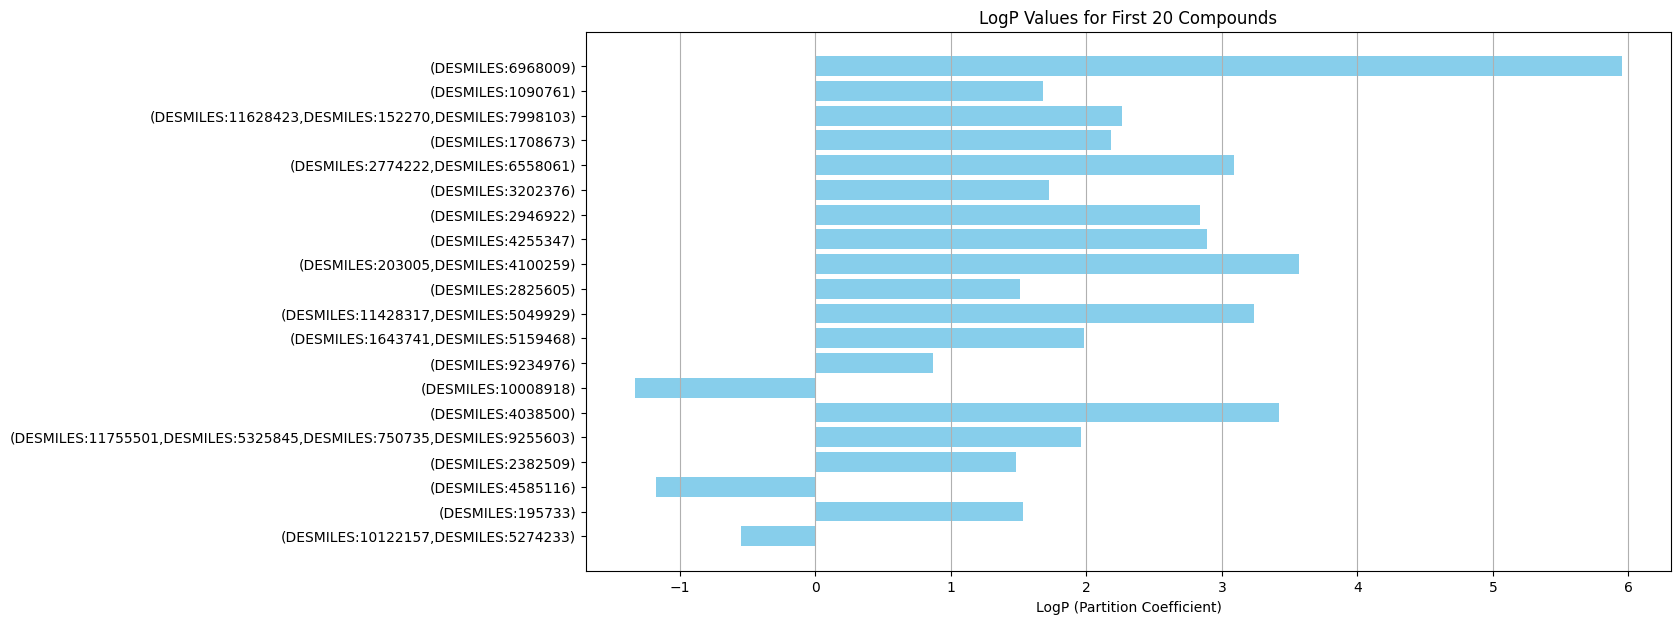

In [7]:
# Bar plot of LogP for first 20 compounds
if 'ID' in df_clean.columns and 'XLogP' in df_clean.columns:
    plt.figure(figsize=(14, 7))
    sample_data = df_clean.head(20)  
    plt.barh(sample_data['ID'], sample_data['XLogP'], color='skyblue')
    plt.xlabel('LogP (Partition Coefficient)')
    plt.title('LogP Values for First 20 Compounds')
    plt.gca().invert_yaxis()  # To have the first compound on top
    plt.grid(True, axis='x')
    plt.show()
else:
    print("Columns 'CompoundName' and/or 'LogP' not found!")


In [8]:
# See actual column names
print(df_clean.columns.tolist())


['ID', 'score', 'SMILES', 'target', 'MW', 'MW_EXACT', 'XLogP', 'HBA', 'HBD', 'LIPINSKI_COUNT', 'RO3_COUNT', 'TPSA_NO', 'TPSA_NOPS', 'HAC', 'AtomCount', 'BondCount', 'FSP3', 'RotBondCount', 'HalogenCount', 'SpiroCount', 'PosCount', 'NegCount', 'ComponentCount', 'SimpleRingCount', 'AromaticRingCount']


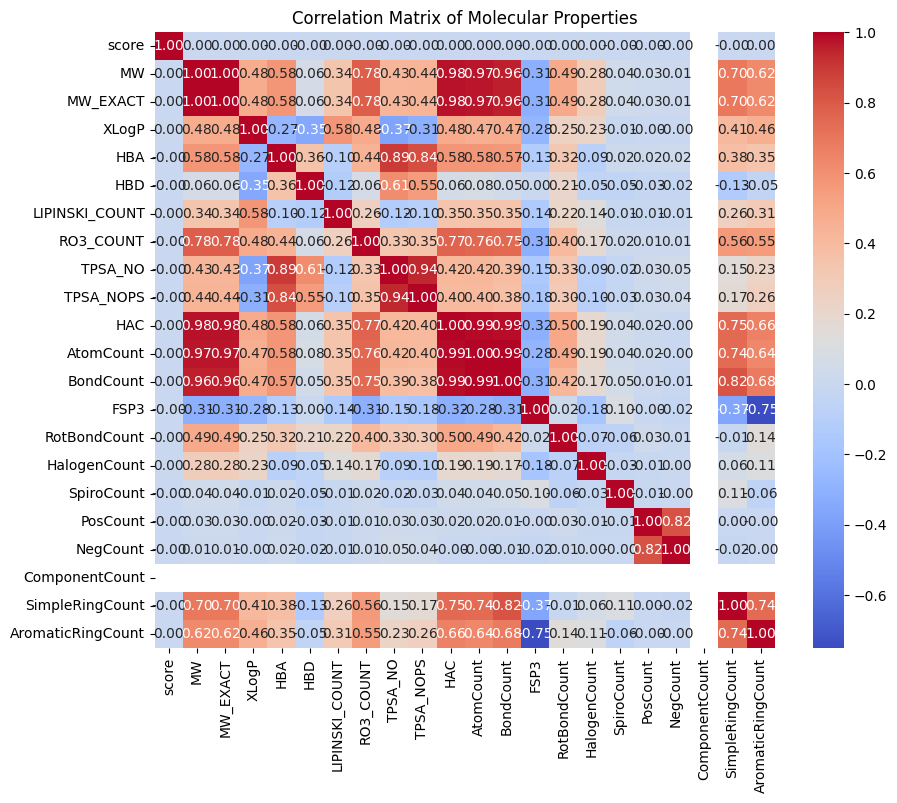

In [12]:
import seaborn as sns
# Select only numeric columns
numeric_df = df_clean.select_dtypes(include=[np.number])

# Now calculate correlation
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Molecular Properties')
plt.show()


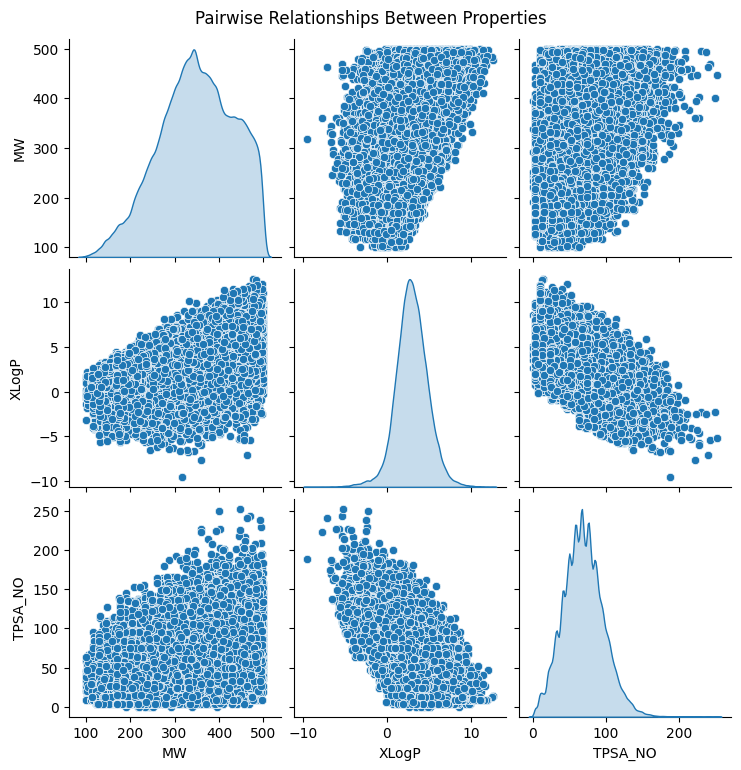

In [14]:
# Selecting only a few columns for pairplot
selected_columns = ['MW', 'XLogP', 'TPSA_NO'] 
sns.pairplot(df_clean[selected_columns], diag_kind='kde')
plt.suptitle('Pairwise Relationships Between Properties', y=1.02)
plt.show()


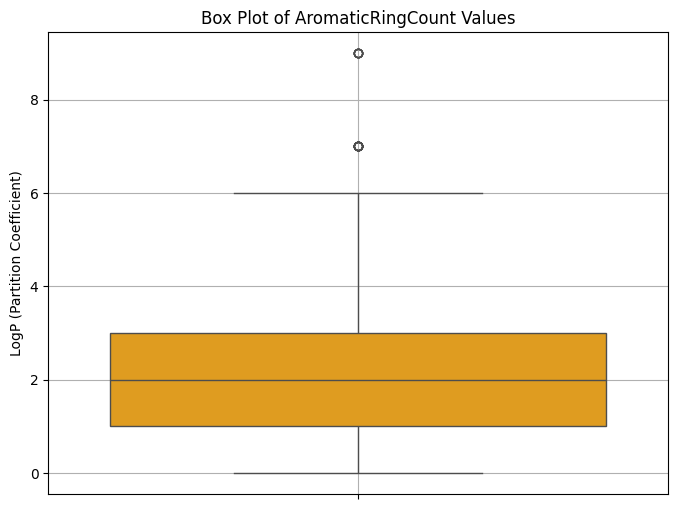

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_clean['AromaticRingCount'], color='orange')
plt.title('Box Plot of AromaticRingCount Values')
plt.ylabel('LogP (Partition Coefficient)')
plt.grid(True)
plt.show()
